# Continuum, Tight-Binding, and Quantum Transport in 1D

This repository studies a one-dimensional free particle and its lattice
realization using tight-binding models. It covers:

1. Continuum–tight-binding scaling
2. The emergence of cosine dispersion from a free particle
3. Tight-binding Hamiltonian and lattice spacing
4. Quantum transport and conductance using Kwant

---

## 1. Continuum Hamiltonian and Scaling

The continuum Hamiltonian of a free particle is

$$
H = \frac{\hbar^2}{2m} k_x^2 - \mu
$$

To compare with a lattice model, we introduce dimensionless variables:

$$
\tilde{k} = k_x a
$$

$$
\tilde{E} = E \frac{2 m a^2}{\hbar^2} = \frac{E}{t}
$$

$$
\tilde{\mu} =  \frac{\mu}{t}
$$

In these units, the dispersion becomes

$$
\tilde{E} = \tilde{k}^2 - \tilde{\mu}
$$

When discretized on a lattice with spacing \(a\), the tight-binding band
converges to the continuum parabola over an increasing momentum range
as \(a \to 0\).

---

## 2. From Free Particle to Cosine Dispersion

For a free particle with chemical potential \(\mu\):

On a one-dimensional lattice with nearest-neighbor hopping \(t\) and lattice
constant \(a\), the tight-binding dispersion is


In the small-\(k\) limit:

$$
\cos(\tilde{k}) \approx 1 - \frac{\tilde{k}^2}{2} \quad \Rightarrow \quad \tilde{k}^2 \approx 2(1 - \cos(\tilde{k}))
$$

which gives

$$
\tilde{E}(\tilde{k}) = 2(1 - \cos(\tilde{k})) - \tilde{\mu}
$$

Matching the quadratic term with the continuum yields:

$$
t = \frac{\hbar^2}{2 m a^2}.
$$

Thus, the cosine band reproduces the free-particle dispersion at low
energies, with the hopping amplitude \(t\) setting the effective mass.

---

## 3. Tight-Binding Hamiltonian and Lattice Spacing

Discretizing the 1D Schrödinger equation on a lattice with spacing \(a\) gives

$$
-\frac{\hbar^2}{2m} \frac{\psi_{i+1} - 2 \psi_i + \psi_{i-1}}{a^2} - \mu \psi_i = E \psi_i,
$$

where \(\psi_i\) is the wavefunction at site \(i\), \(\mu\) is the chemical potential,
and \(E\) is the energy.

In tight-binding notation:

**Onsite term:**

$$
H_{\text{onsite}} = 2 t - \mu
$$

**Hopping term:**

$$
H_{\text{hop}} = -t
$$

with

$$
t = \frac{\hbar^2}{2 m a^2}, \qquad
H_{\text{onsite}} = \frac{\hbar^2}{m a^2} - \mu.
$$

**Remark:** When changing the lattice spacing \(a\), both \(t\) and the
onsite term \(2t-\mu\) must be updated. Otherwise, the energy scale does not change.

---

## 4. Tight-Binding Chain and Quantum Transport

A finite tight-binding chain of length \(L\) has onsite energy \(2t-\mu\)
and nearest-neighbor hopping \(-t\):

$$
H = \sum_n (2t - \mu)\, c_n^\dagger c_n
- t \sum_n \left( c_{n+1}^\dagger c_n + \text{h.c.} \right).
$$

The system is connected to two semi-infinite leads with the same hopping \(t\)
and chemical potential \(\mu_{\text{lead}}\).

Different lattice spacings \(a\) can be studied by updating \(t = 1/a^2\)
and constructing the corresponding system.

---

In [14]:
import matplotlib.pyplot as plt

import numpy as np
import scipy

import kwant
import kwant.continuum

import scienceplots
plt.style.use(['science', 'notebook'])

# Band Structure

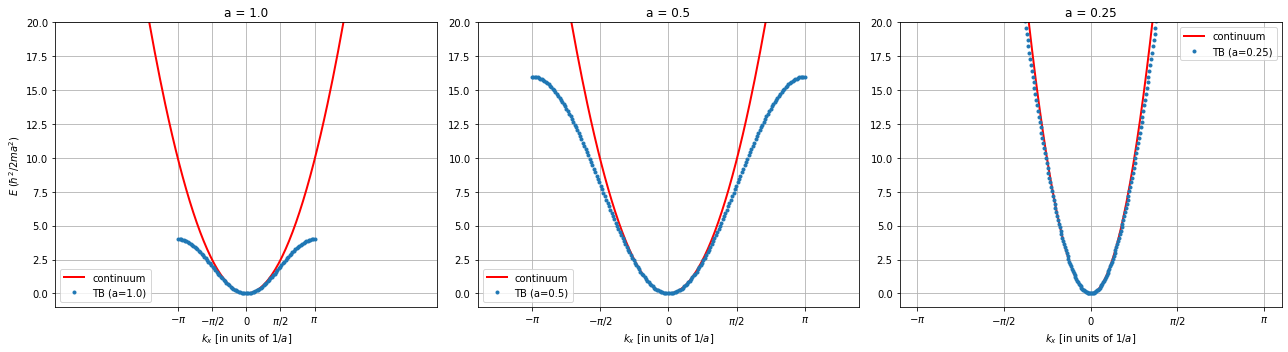

In [11]:
import kwant
import numpy as np
from matplotlib import pyplot as plt

# ------------------------
# Continuum Hamiltonian
# ------------------------
hamiltonian = "k_x**2 - mu"
params = dict(mu = 0)
H_k = kwant.continuum.lambdify(hamiltonian, locals=params)
k_cont = np.linspace(-8, 8, 200)
e_cont = [H_k(k_x=k) for k in k_cont]

# ------------------------
# Lattice spacings to test
# ------------------------
a_list = [1.0, 0.5, 0.25]

# ------------------------
# Subplots
# ------------------------
fig, axes = plt.subplots(1, len(a_list), figsize=(6*len(a_list),5), sharey=False)
y_limits = [(-1, 20), (-1, 20), (-1, 20)]

for i, a in enumerate(a_list):
    ax = axes[i]
    
    # Tight-binding
    template = kwant.continuum.discretize(hamiltonian, grid=a)
    lead = kwant.Builder(kwant.TranslationalSymmetry([-a]))
    lead.fill(template, shape=lambda site: True, start=[0])
    lead = lead.finalized()
    bands = kwant.physics.Bands(lead, params=params)
    
    # Momentum arrays
    k_tb = np.linspace(-np.pi/a, np.pi/a, int(100/a))
    e_tb = [bands(k*a) for k in k_tb]
    
    # Plot continuum
    ax.plot(k_cont, e_cont, 'r-', lw=2, label='continuum')
    # Plot tight-binding
    ax.plot(k_tb, e_tb, '.', lw=2, label=f'TB (a={a})')
    
    ax.set_title(f'a = {a}')
    ax.grid(True)
    ax.legend()
    ax.set_ylim(y_limits[i])
    
    # ------------------------
    # X ticks in units of pi
    # ------------------------
    ticks = np.array([-np.pi, -np.pi/2, 0, np.pi/2, np.pi]) / a  # normalize to 1/a
    labels = [r"$-\pi$", r"$-\pi/2$", r"$0$", r"$\pi/2$", r"$\pi$"]
    ax.set_xticks(ticks)
    ax.set_xticklabels(labels)

# Common labels
axes[0].set_ylabel(r"$E\;(\hbar^2 / 2 m a^2)$")
for ax in axes:
    ax.set_xlabel(r"$k_x$ [in units of $1/a$]")

plt.tight_layout()
plt.show()

# Conductance

In [3]:
def make_system(L, mu, mu_lead, a, t):
    lat = kwant.lattice.chain(a, norbs=1)
    syst = kwant.Builder()
    syst[(lat(i) for i in range(L))] = 2 * t - mu
    syst[kwant.builder.HoppingKind((1,), lat)] = -t

    left_lead = kwant.Builder(kwant.TranslationalSymmetry((-a,)))
    left_lead[(lat(0))] = 2 * t - mu_lead
    left_lead[kwant.builder.HoppingKind((-1,), lat)] = -t

    syst.attach_lead(left_lead)
    syst.attach_lead(left_lead.reversed())
    return syst

In [4]:
# Parameters
L = 50
mu = 0
mu_lead = 0

/usr/local/lib/python3.10/dist-packages/kwant/_plotter.py:77: RuntimeWarning: plotly is not available, if other engines are unavailable, only iterator-providing functions will work
  warnings.warn("plotly is not available, if other engines are unavailable,"


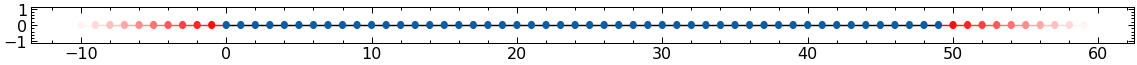

In [5]:
syst = make_system(L, mu, mu_lead, a=1, t=1)
fig, ax = plt.subplots(1, 1, figsize=(16,1.1))
#ax.set_ylim(-1,1)
kwant.plot(syst, ax=ax, show=True, num_lead_cells=10, hop_color='black')
plt.tight_layout()
plt.savefig('system_1D.svg')
#plt.show()

In [6]:
def compute_conductance(fsyst, energies):
    data = []
    for energy in energies:
        smatrix = kwant.smatrix(fsyst, energy)
        data.append(smatrix.transmission(1, 0))
    return np.array(data)

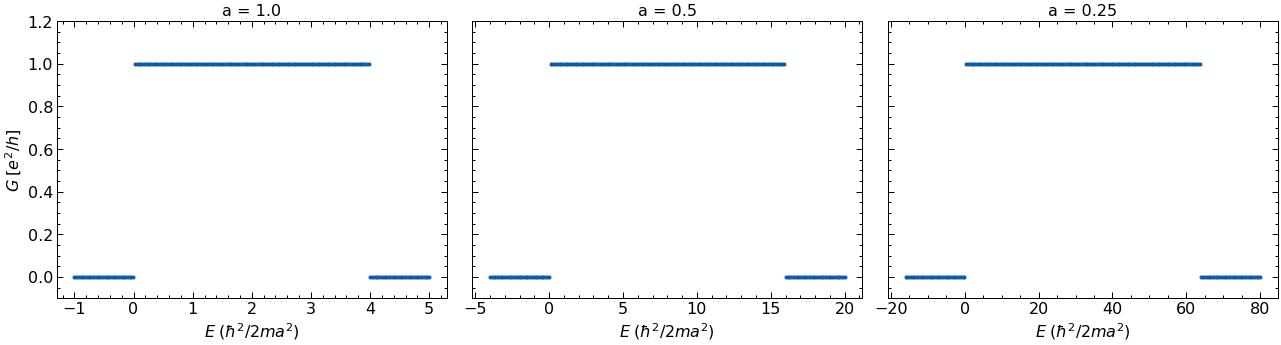

In [7]:
a_values = [1.0, 0.5, 0.25]  # Lattice spacings
# Subplots: 1 row, len(a_values) columns
fig, axes = plt.subplots(1, len(a_values), figsize=(6*len(a_values),5), sharey=True)

# Eğer sadece bir subplot olursa axes tek objeye dönüşebileceği için listeye al
if len(a_values) == 1:
    axes = [axes]

for i, a in enumerate(a_values):
    t = 1 / a**2
    syst = make_system(L, mu, mu_lead, a, t)
    fsyst = syst.finalized()
    
    E0 = 2*t - mu
    energies = np.linspace(E0 - 3*t, E0 + 3*t, 200)
    
    G = compute_conductance(fsyst, energies)
    axes[i].plot(energies, G, '.')
    axes[i].set_title(f'a = {a}')
    axes[i].set_ylim(-0.1, 1.2)  # isteğe göre ayrı ayarlayabilirsin

# Common labels
axes[0].set_ylabel(r"$G \; [e^2/h]$")
for ax in axes:
    ax.set_xlabel(r"$E\;(\hbar^2 / 2 m a^2)$")

plt.tight_layout()
plt.show()